In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

obs_per_rollout = []
for roll in os.listdir('../data/latent32_vizdoom_2.5k'):
    data = np.load('../data/latent32_vizdoom_2.5k/' + roll)
    lat_obs = data['latent_observations']
    obs_per_rollout.append(lat_obs.shape[0])

plt.figure(figsize=(10, 6))
plt.hist(obs_per_rollout, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Observations per Rollout')
plt.ylabel('Frequency')
plt.title('Distribution of Observations per Rollout')
plt.grid(True, alpha=0.3)
plt.show()

print(f'Total rollouts: {len(obs_per_rollout)}')
print(f'Avg observations per rollout: {np.mean(obs_per_rollout):.2f}')
print(f'Min observations: {np.min(obs_per_rollout)}')
print(f'Max observations: {np.max(obs_per_rollout)}')

In [1]:
import sys
sys.path.append('..')
from data.dataset import LatentSequenceDataset

d = LatentSequenceDataset('/media/fanis/Intenso/wm18/latent64_vizdoom_1_32_2.5k')

Pre-loading all data into memory, this might take a moment...


Pre-loading data into RAM: 100%|██████████| 2450/2450 [00:57<00:00, 42.79it/s]


Data pre-loading complete.
[LatentSequenceDataset] pos_weight = 362.7196 (negatives=888663, positives=2450)
Generating sequence indices...


Generating indices: 100%|██████████| 2450/2450 [00:00<00:00, 7203.20it/s] 

[LatentSequenceDataset] Loaded 646151 sequences from 2435 files. Discarded 15/2450 files smaller than 100 frames.


In [14]:
it = iter(d)
x, y = next(it)
x[86][-1]

tensor(1.)

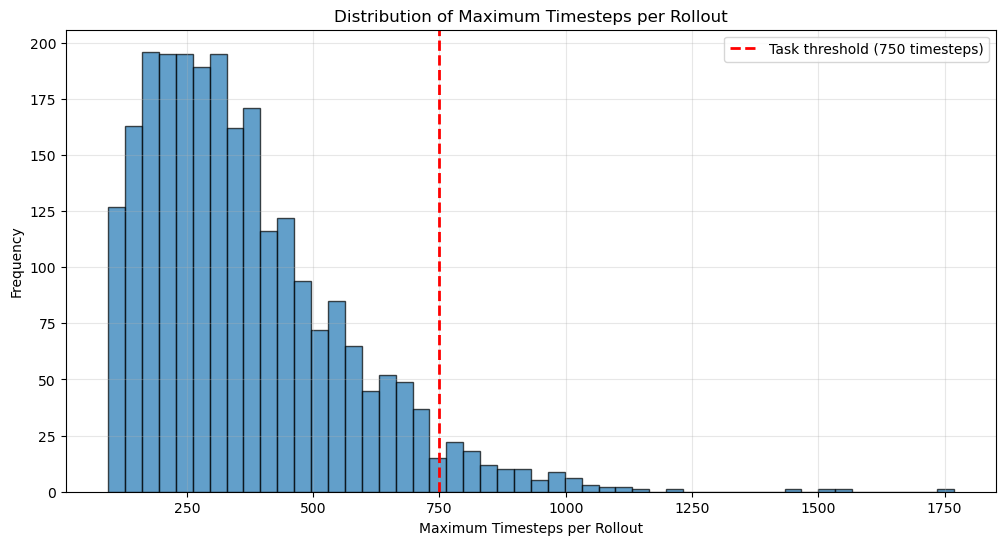

Total rollouts: 2450
Average timesteps per rollout: 363.72
Min timesteps: 94
Max timesteps: 1768
Median timesteps: 321.00
Std deviation: 196.82

Task Analysis:
Rollouts >= 750 timesteps: 113/2450 (4.6%)
Task solved if avg > 750: ✗ NO

Sequence Length Filtering (seq_len=150):
Valid rollouts (>= 150 timesteps): 2206/2450 (90.0%)
Discarded rollouts (< 150 timesteps): 244 (10.0%)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the number of timesteps for each episode/rollout
timesteps_per_rollout = []
for episode in d.episodes:
    # Get the length of the latents tensor for each episode
    num_timesteps = episode['latents'].shape[0]
    timesteps_per_rollout.append(num_timesteps)

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(timesteps_per_rollout, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=750, color='red', linestyle='--', linewidth=2, label='Task threshold (750 timesteps)')
plt.xlabel('Maximum Timesteps per Rollout')
plt.ylabel('Frequency')
plt.title('Distribution of Maximum Timesteps per Rollout')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print statistics
print(f'Total rollouts: {len(timesteps_per_rollout)}')
print(f'Average timesteps per rollout: {np.mean(timesteps_per_rollout):.2f}')
print(f'Min timesteps: {np.min(timesteps_per_rollout)}')
print(f'Max timesteps: {np.max(timesteps_per_rollout)}')
print(f'Median timesteps: {np.median(timesteps_per_rollout):.2f}')
print(f'Std deviation: {np.std(timesteps_per_rollout):.2f}')

# Task completion analysis
above_threshold = np.array(timesteps_per_rollout) >= 750
percentage_above = (above_threshold.sum() / len(timesteps_per_rollout)) * 100
# Add seq_len parameter for filtering analysis
seq_len = 150  # You can adjust this value as needed

# Filter rollouts based on seq_len
valid_rollouts = np.array(timesteps_per_rollout) >= seq_len
discarded_rollouts = len(timesteps_per_rollout) - valid_rollouts.sum()
percentage_discarded = (discarded_rollouts / len(timesteps_per_rollout)) * 100

print(f'\nTask Analysis:')
print(f'Rollouts >= 750 timesteps: {above_threshold.sum()}/{len(timesteps_per_rollout)} ({percentage_above:.1f}%)')
print(f'Task solved if avg > 750: {"✓ YES" if np.mean(timesteps_per_rollout) > 750 else "✗ NO"}')

print(f'\nSequence Length Filtering (seq_len={seq_len}):')
print(f'Valid rollouts (>= {seq_len} timesteps): {valid_rollouts.sum()}/{len(timesteps_per_rollout)} ({100-percentage_discarded:.1f}%)')
print(f'Discarded rollouts (< {seq_len} timesteps): {discarded_rollouts} ({percentage_discarded:.1f}%)')